# Mobile Money In Africa

In [84]:
# Importing all required libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [73]:
Registered_Accounts = pd.read_csv("../Datasets/Registered_Accounts.csv")
Registered_Accounts.head()

,Date,Clean Date,Northern Africa,Eastern Africa,Southern Africa,Western Africa,Sub-Saharan Africa
0,Dec-11,12/01/11,49656.0,39836904.0,463200,6768709.0,47324930
1,Mar-12,03/01/12,53076.0,44189814.0,541375,8536718.0,53647306
2,Jun-12,06/01/12,89938.0,49229726.0,625960,9792990.0,60332950
3,Sep-12,09/01/12,137413.0,51953008.0,861099,10172703.0,64712998
4,Dec-12,12/01/12,200723.0,56991820.0,1222403,12499816.0,73399764


In [74]:
#Converting all columns names to lowercase
Registered_Accounts.columns = Registered_Accounts.columns.str.lower()

# Remove leading/trailing spaces and replace internal spaces with underscores
Registered_Accounts.columns = Registered_Accounts.columns.str.strip().str.replace(' ', '_')

print(Registered_Accounts.columns.tolist())

['date', 'clean_date', 'northern_africa', 'eastern_africa', 'southern_africa', 'western_africa', 'sub-saharan_africa']


In [75]:
Registered_Accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                53 non-null     object 
 1   clean_date          53 non-null     object 
 2   northern_africa     53 non-null     float64
 3   eastern_africa      53 non-null     float64
 4   southern_africa     53 non-null     int64  
 5   western_africa      53 non-null     float64
 6   sub-saharan_africa  53 non-null     int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 3.0+ KB


In [76]:
Registered_Accounts["clean_date"] = pd.to_datetime(Registered_Accounts["clean_date"])

/tmp/ipykernel_44323/3784108915.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Registered_Accounts["clean_date"] = pd.to_datetime(Registered_Accounts["clean_date"])


In [77]:
Registered_Accounts["clean_date"].head()
# Registered_Accounts["date"].dtype

0   2011-12-01
1   2012-03-01
2   2012-06-01
3   2012-09-01
4   2012-12-01
Name: clean_date, dtype: datetime64[ns]

In [78]:
Registered_Accounts.isnull().sum()

date                  0
clean_date            0
northern_africa       0
eastern_africa        0
southern_africa       0
western_africa        0
sub-saharan_africa    0
dtype: int64

In [ ]:
Registered_Accounts.describe(include = np.number).T

### Exploratory Data Analysis for Registered Accounts

In [92]:
Registered_Acc_Dec_raw = Registered_Accounts[
    Registered_Accounts["clean_date"].dt.month == 12
].copy()

In [93]:
# Extracting the year from the clean date column
# (Errors='coerce' handles any messy strings safely)
Registered_Acc_Dec_raw["Year"] = pd.to_datetime(Registered_Acc_Dec_raw["clean_date"]).dt.year

In [94]:
Registered_Acc_Dec = Registered_Acc_Dec_raw.melt(
    id_vars=["date", "clean_date"], # "date" is preserved here
    value_vars=[
        "northern_africa",
        "eastern_africa",
        "southern_africa",
        "western_africa",
        "sub-saharan_africa"
    ],
    var_name="Region",
    value_name="Value"
)

In [95]:
Registered_Acc_Dec["Value"] = pd.to_numeric(Registered_Acc_Dec["Value"])

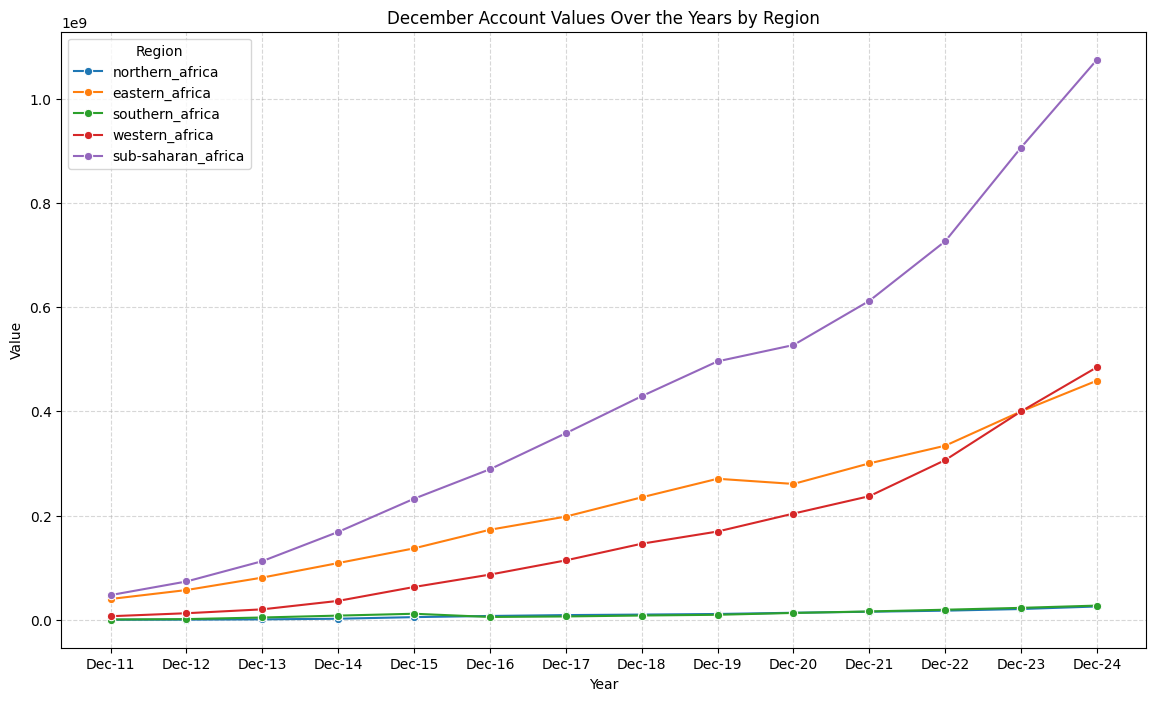

In [99]:
# 3. Plot using "date" as your X-axis
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=Registered_Acc_Dec,
    x="date",          # Using 'date' directly since it represents the years
    y="Value",
    hue="Region",
    marker="o"
)

plt.title("December Account Values Over the Years by Region")
plt.xlabel("Year")
plt.ylabel("Value")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()